In [1]:
%pip install sentence-transformers rank-bm25 xgboost lightgbm -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import re
import json
import logging
import warnings
import random

import numpy as np
import pandas as pd

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sentence_transformers import SentenceTransformer, CrossEncoder

from rank_bm25 import BM25Okapi

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [4]:
# =========================================================
# DIRECTORY CONFIGURATION
# =========================================================

ROOT_DIR = "/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan"

DATA_PATH = os.path.join(
    ROOT_DIR,
    "data",
    "processed",
    "cases.csv"
)

RESULT_DIR = os.path.join(
    ROOT_DIR,
    "data",
    "results"
)

EVAL_DIR = os.path.join(
    ROOT_DIR,
    "data",
    "eval"
)

VIS_DIR = os.path.join(
    ROOT_DIR,
    "visualizations"
)

MODEL_DIR = os.path.join(
    ROOT_DIR,
    "models"
)

LOG_DIR = os.path.join(
    ROOT_DIR,
    "logs"
)

for path in [
    RESULT_DIR,
    EVAL_DIR,
    VIS_DIR,
    MODEL_DIR,
    LOG_DIR
]:
    os.makedirs(path, exist_ok=True)

In [5]:
# =========================================================
# LOGGING
# =========================================================

LOG_PATH = os.path.join(
    LOG_DIR,
    "retrieval.log"
)

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename=LOG_PATH,
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    filemode="w"
)

logging.info("===== NOTEBOOK 03 STARTED =====")

In [6]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(30, 12)


,case_id,nomor_putusan,tahun,pengadilan,terdakwa,pasal,jenis_putusan,dakwaan,ringkasan_fakta,amar_putusan,full_text,retrieval_topic
0,case_001,1105/2016/S.270/TAH.SUS.IK/PP/2016/MATANGGAL29,2016,Pengadilan Negeri sejak,SOPIAN BINRABBIL | SARIF BINCU | SAMSULBINKOHE...,Pasal 8 ayat (1); Pasal 9; Pasal 46; Pasal 39;...,Bom Ikan,didakwa:KESATU :BahwaTerdakwaISOPIAN binRABBIL...,pada hari senin tanggal 02 nopember 2015sekira...,"mengadili,“Mereka yang melakukan, yang menyuru...",: Halaman 1 dari13hal. Put. Nomor :497K/Pid.Su...,Bom Ikan
1,case_002,7/AKTA-KASASI.PID.SUS-PRK/2017/PN.MDN,2017,Pengadilan Negeri Me,RIZAL | NAMA RIZAL,Pasal 9 ayat (1); Pasal 85; Pasal 98; Pasal 9,Trawl,didakwa dengan dakwaan sebagai berikut:Dakwaan...,bahwa terdakwa melanggar pasal 98 undang-undan...,MENGADILI SENDIRI:1.Menyatakan Terdakwa Rizal ...,: Halaman 1 PUTUSANNomor 102 K/Pid.Sus/2018DEM...,Trawl
2,case_003,3370/2016/S.853.TAH.SUS.IK/PP/2016/MA.TANGGAL,2016,Pengadilan Negeri Palembang,GINDA PURNAMABIN TEGIN | NAMA GINDA PURNAMABIN...,Pasal 30; Pasal 162; Pasal 253 Ayat (1); Pasal...,Trawl,didakwa dengan dakwaan sebagai berikut :Bahwa ...,"pada hari kamis,tanggal 4 februari 2016 sekira...",mengadili Pengadilan NegeriPalembang dikarenak...,: Halaman 1 dari18hal. Put. No.1442K/PID.SUS/2...,Trawl
3,case_004,88/PID.SUS/2015/PN.WNO.,2015,Pengadilan Negeri Wonosari,N A M A LENGKAP SUGIANTORO BIN SAINO ALIAS GIANTO,pasal 42 ayat (3); pasal 27 ayat (1); pasal 98...,Tanpa SIPI,didakwa sebagai berikut : Kesatu: Bahwa terdak...,bahwa terdakwa sugiyantoro als. giyanto bin sa...,mengadili Perkara Pidana dalam tingkat banding...,: Halaman 1 Nomor 84/PID.SUS/2015/PT YYK. PUTU...,Tanpa SIPI
4,case_005,24/AKTA.PID.SUS-PRK/2018/PNRANJUNCTONOMOR,2018,Pengadilan Negeri Ranai,TRAN VAN TRUONG | NAMA TRAN VAN TRUONG,Pasal 9; Pasal 102; Pasal 55; Pasal 92; Pasal ...,Trawl,didakwa dengan dakwaan sebagai berikut:-Kesatu...,bahwa terdakwa mengakuibelumpernah dihukum sed...,mengadili sendiri perkara inidengan amar putus...,: Halaman 1 dari9hal. Putusan Nomor1335K/Pid.S...,Trawl


In [7]:
# =========================================================
# CLEAN TEXT
# =========================================================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z0-9\s/]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

In [8]:
# =========================================================
# CREATE COMBINED TEXT
# =========================================================

df["combined_text"] = (

    df["retrieval_topic"].fillna("") + " " +

    df["ringkasan_fakta"].fillna("") + " " +

    df["pasal"].fillna("") + " " +

    df["jenis_putusan"].fillna("") + " " +

    df["dakwaan"].fillna("")
)

df["clean_text"] = df["combined_text"].apply(clean_text)

print(df["clean_text"].head())

0    bom ikan pada hari senin tanggal 02 nopember 2...
1    trawl bahwa terdakwa melanggar pasal 98 undang...
2    trawl pada hari kamis tanggal 4 februari 2016 ...
3    tanpa sipi bahwa terdakwa sugiyantoro als giya...
4    trawl bahwa terdakwa mengakuibelumpernah dihuk...
Name: clean_text, dtype: object


In [9]:
# =========================================================
# REMOVE EMPTY TEXT
# =========================================================

df = df[
    df["clean_text"].str.len() > 20
]

df = df.reset_index(drop=True)

print(df.shape)

logging.info(f"VALID DOCUMENTS: {len(df)}")

(30, 14)


In [10]:
# =========================================================
# AUTO GENERATE QUERIES
# =========================================================

queries = []

query_mapping = {

    "Bom Ikan":
    "penangkapan ikan menggunakan bahan peledak",

    "Trawl":
    "penggunaan alat tangkap pukat harimau",

    "Tanpa SIPI":
    "penangkapan ikan tanpa surat izin penangkapan ikan",

    "Tanpa SIUP":
    "usaha perikanan tanpa surat izin usaha perikanan",

    "Tanpa SPB":
    "kapal tanpa surat persetujuan berlayar",

    "Kapal Asing":
    "kapal asing melakukan penangkapan ikan",

    "Perikanan Umum":
    "tindak pidana perikanan"
}

for i, row in df.iterrows():

    topic = row["retrieval_topic"]

    query = query_mapping.get(
        topic,
        "tindak pidana perikanan"
    )

    queries.append({

        "query_id":
        i + 1,

        "query":
        query,

        "ground_truth":
        row["case_id"]
    })

print("Total Query:", len(queries))

Total Query: 30


In [11]:
QUERY_PATH = os.path.join(
    EVAL_DIR,
    "queries.json"
)

with open(
    QUERY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        queries,
        f,
        indent=4,
        ensure_ascii=False
    )

print("queries.json saved")

queries.json saved


In [12]:
# =========================================================
# TF-IDF VECTORIZATION
# =========================================================

tfidf = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,2),

    stop_words=None
)

tfidf_matrix = tfidf.fit_transform(
    df["clean_text"]
)

print(tfidf_matrix.shape)

logging.info("TF-IDF COMPLETED")

(30, 10000)


In [13]:
# =========================================================
# BM25 PREPARATION
# =========================================================

tokenized_corpus = [

    doc.split()

    for doc in df["clean_text"]
]

bm25 = BM25Okapi(tokenized_corpus)

logging.info("BM25 INITIALIZED")

In [14]:
# =========================================================
# SENTENCE TRANSFORMER
# =========================================================

embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

embeddings = embedding_model.encode(

    df["clean_text"].tolist(),

    show_progress_bar=True
)

print(embeddings.shape)

logging.info("BERT EMBEDDINGS CREATED")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(30, 384)


In [15]:
# =========================================================
# CROSS ENCODER
# =========================================================

cross_encoder = CrossEncoder(
    'cross-encoder/ms-marco-MiniLM-L-6-v2'
)

logging.info("CROSS ENCODER LOADED")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [16]:
# =========================================================
# QUERY EXPANSION
# =========================================================

query_dictionary = {

    "bahan peledak":
    "bom ikan peledak potasium detonator",

    "pukat harimau":
    "trawl alat tangkap jaring",

    "tanpa surat izin penangkapan ikan":
    "sipi izin penangkapan ikan",

    "tanpa surat izin usaha perikanan":
    "siup izin usaha perikanan",

    "tanpa surat persetujuan berlayar":
    "spb surat persetujuan berlayar",

    "kapal asing":
    "vietnam thailand china malaysia berbendera asing"
}
def expand_query(query):

    query = query.lower()

    expanded = query

    for key, value in query_dictionary.items():

        if key in query:

            expanded += " " + value

    return expanded

In [17]:
# =========================================================
# HYBRID RETRIEVAL
# =========================================================

def retrieve_hybrid(query, k=5):

    query = expand_query(query)

    query = clean_text(query)

    # TF-IDF

    query_tfidf = tfidf.transform([query])

    tfidf_scores = cosine_similarity(

        query_tfidf,

        tfidf_matrix

    ).flatten()

    # BM25

    bm25_scores = bm25.get_scores(
        query.split()
    )

    # BERT

    query_embedding = embedding_model.encode(
        [query]
    )

    bert_scores = cosine_similarity(

        query_embedding,

        embeddings

    ).flatten()

    # NORMALIZATION

    tfidf_norm = (

        tfidf_scores - tfidf_scores.min()

    ) / (

        tfidf_scores.max() - tfidf_scores.min() + 1e-10
    )

    bm25_norm = (

        bm25_scores - np.min(bm25_scores)

    ) / (

        np.max(bm25_scores) - np.min(bm25_scores) + 1e-10
    )

    bert_norm = (

        bert_scores - bert_scores.min()

    ) / (

        bert_scores.max() - bert_scores.min() + 1e-10
    )

    # HYBRID SCORE
    final_scores = (

    0.20 * tfidf_norm +

    0.35 * bm25_norm +

    0.45 * bert_norm
)

    top_indices = final_scores.argsort()[::-1][:10]

    # CROSS ENCODER RERANKING

    pairs = [

        (query, df.iloc[idx]["clean_text"])

        for idx in top_indices
    ]

    rerank_scores = cross_encoder.predict(pairs)

    reranked = sorted(

        zip(top_indices, rerank_scores),

        key=lambda x: x[1],

        reverse=True
    )

    reranked = reranked[:k]

    results = []

    for idx, score in reranked:

        results.append({

            "case_id":
            df.iloc[idx]["case_id"],

            "nomor_putusan":
            df.iloc[idx]["nomor_putusan"],

            "similarity":
            float(score),

            "jenis_putusan":
            df.iloc[idx]["jenis_putusan"],

            "pasal":
            df.iloc[idx]["pasal"]
        })

    logging.info(
        f"QUERY SUCCESS: {query}"
    )

    return pd.DataFrame(results)

In [18]:
# =========================================================
# TEST RETRIEVAL
# =========================================================

query = """
terdakwa melakukan penangkapan ikan
tanpa surat izin penangkapan ikan
menggunakan kapal ikan
"""

result = retrieve_hybrid(query, k=5)

result

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,case_id,nomor_putusan,similarity,jenis_putusan,pasal
0,case_022,09/PID.K/2010/PN.TPI,5.435587,Trawl,Pasal 55; Pasal 55 ayat (1); Pasal 85; Pasal 2...
1,case_026,5/PID.SUS-PRK/,4.794043,Tanpa SIPI,Pasal 33 ayat (3); Pasal 35; Pasal 41 ayat (3)...
2,case_029,112/PID.B/2009/PN.TPI,4.255013,Trawl,Pasal 197; Pasal 55; Pasal 55 ayat (1); Pasal ...
3,case_019,280/PID/2009/PTR,4.237996,Trawl,Pasal 197; Pasal 55; Pasal 253; Pasal 85; Pasa...
4,case_004,88/PID.SUS/2015/PN.WNO.,4.106945,Tanpa SIPI,pasal 42 ayat (3); pasal 27 ayat (1); pasal 98...


In [19]:
print(df.columns.tolist())

['case_id', 'nomor_putusan', 'tahun', 'pengadilan', 'terdakwa', 'pasal', 'jenis_putusan', 'dakwaan', 'ringkasan_fakta', 'amar_putusan', 'full_text', 'retrieval_topic', 'combined_text', 'clean_text']


In [20]:
pd.set_option('display.max_colwidth', None)

print(df.iloc[0])

case_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [21]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df.iloc[0][col])

case_id
case_001
nomor_putusan
1105/2016/S.270/TAH.SUS.IK/PP/2016/MATANGGAL29
tahun
2016
pengadilan
Pengadilan Negeri sejak
terdakwa
SOPIAN BINRABBIL | SARIF BINCU | SAMSULBINKOHER | I.NAMA LENGKAP SOPIAN BINRABBIL
pasal
Pasal 8 ayat (1); Pasal 9; Pasal 46; Pasal 39; Pasal 55; Pasal 84 ayat (1); Pasal 9 ayat (1); Pasal 55 ayat (1); Pasal 85; Pasal 76
jenis_putusan
Bom Ikan
dakwaan
didakwa:KESATU :BahwaTerdakwaISOPIAN binRABBIL,TerdakwaIISARIF bin CUdanTerdakwaIIISAMSUL bin KOHER, pada hari Senin tanggal 02 Nopember 2015sekira pukul 12.15 wita atau setidak-tidaknya pada suatu waktu tertentu dalambulan Nopember tahun 2015, bertempat di Perairan laut Kandolo BontangKalimantan Timur atau setidak-tidaknya pada suatu tempat lain yang masihtermasuk dalam daerah hukum Pengadilan Negeri Bontang yang berwenangmemeriksa dan mengadili,“Mereka yang melakukan, yang menyuruhmelakukan, dan yang turut serta melakukan perbuatan yang dengan sengaja diwilayah pengelolaan perikanan Republik Indonesia melak

In [22]:
# =========================================================
# EVALUATION
# =========================================================

evaluation_results = []

for q in queries:

    retrieved = retrieve_hybrid(
        q["query"],
        k=5
    )

    retrieved_ids = retrieved[
        "case_id"
    ].tolist()

    hit = int(
        q["ground_truth"] in retrieved_ids
    )

    evaluation_results.append({

        "query_id":
        q["query_id"],

        "query":
        q["query"],

        "ground_truth":
        q["ground_truth"],

        "retrieved":
        str(retrieved_ids),

        "hit@5":
        hit
    })

eval_df = pd.DataFrame(
    evaluation_results
)

eval_df

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,query_id,query,ground_truth,retrieved,hit@5
0,1,penangkapan ikan menggunakan bahan peledak,case_001,"['case_001', 'case_010', 'case_022', 'case_025', 'case_030']",1
1,2,penggunaan alat tangkap pukat harimau,case_002,"['case_022', 'case_029', 'case_019', 'case_003', 'case_013']",0
2,3,penggunaan alat tangkap pukat harimau,case_003,"['case_022', 'case_029', 'case_019', 'case_003', 'case_013']",1
3,4,penangkapan ikan tanpa surat izin penangkapan ikan,case_004,"['case_022', 'case_026', 'case_009', 'case_004', 'case_019']",1
4,5,penggunaan alat tangkap pukat harimau,case_005,"['case_022', 'case_029', 'case_019', 'case_003', 'case_013']",0
5,6,penangkapan ikan menggunakan bahan peledak,case_006,"['case_001', 'case_010', 'case_022', 'case_025', 'case_030']",0
6,7,usaha perikanan tanpa surat izin usaha perikanan,case_007,"['case_007', 'case_021', 'case_008', 'case_028', 'case_026']",1
7,8,tindak pidana perikanan,case_008,"['case_008', 'case_015', 'case_011', 'case_021', 'case_030']",1
8,9,penangkapan ikan tanpa surat izin penangkapan ikan,case_009,"['case_022', 'case_026', 'case_009', 'case_004', 'case_019']",1
9,10,penangkapan ikan menggunakan bahan peledak,case_010,"['case_001', 'case_010', 'case_022', 'case_025', 'case_030']",1


In [23]:
# =========================================================
# SAVE EVALUATION
# =========================================================

EVAL_RESULT_PATH = os.path.join(
    RESULT_DIR,
    "retrieval_evaluation.csv"
)

eval_df.to_csv(
    EVAL_RESULT_PATH,
    index=False
)

print(EVAL_RESULT_PATH)

logging.info(
    "Evaluation saved"
)

/content/drive/MyDrive/2023-453_PenalaranKomputerB/SubCPMK3/perikanan/data/results/retrieval_evaluation.csv


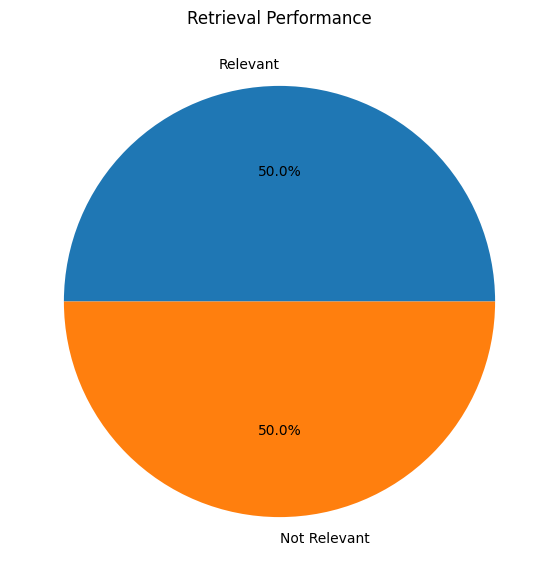

In [24]:
# =========================================================
# VISUALIZATION - HIT@5
# =========================================================

hit_counts = eval_df["hit@5"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(

    hit_counts,

    labels=["Relevant", "Not Relevant"],

    autopct='%1.1f%%'
)

plt.title("Retrieval Performance")

VIS_PATH = os.path.join(
    VIS_DIR,
    "retrieval_hit_pie.png"
)

# Ensure the directory exists before saving
os.makedirs(os.path.dirname(VIS_PATH), exist_ok=True)

plt.savefig(
    VIS_PATH,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

logging.info(
    "Visualization saved"
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

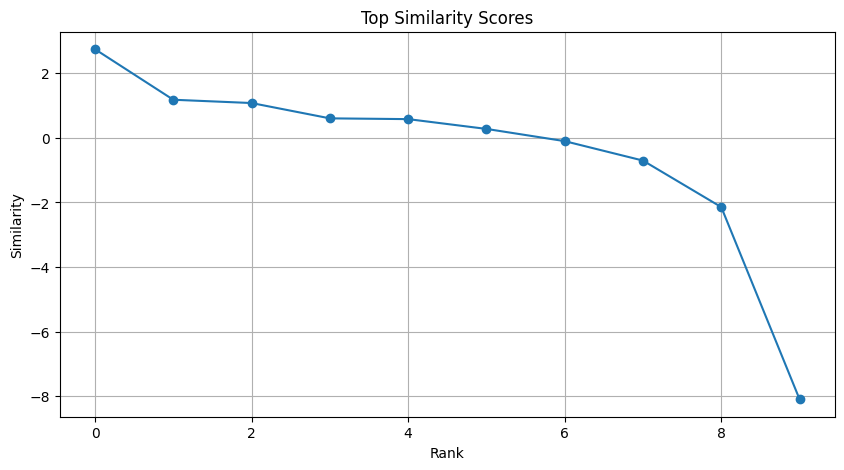

In [25]:
import os

# =========================================================
# VISUALIZATION - SIMILARITY DISTRIBUTION
# =========================================================

sample_query = """
penangkapan ikan ilegal
"""

sample_result = retrieve_hybrid(
    sample_query,
    k=10
)

plt.figure(figsize=(10,5))

plt.plot(

    sample_result["similarity"],

    marker='o'
)

plt.title(
    "Top Similarity Scores"
)

plt.xlabel("Rank")

plt.ylabel("Similarity")

plt.grid(True)

VIS_PATH = os.path.join(
    VIS_DIR,
    "similarity_distribution.png"
)

# Ensure the directory exists before saving
os.makedirs(os.path.dirname(VIS_PATH), exist_ok=True)

plt.savefig(
    VIS_PATH,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [26]:
# =========================================================
# SAVE MODEL ARTIFACTS
# =========================================================

import pickle

TFIDF_PATH = os.path.join(
    MODEL_DIR,
    "tfidf_vectorizer.pkl"
)

EMBEDDING_PATH = os.path.join(
    MODEL_DIR,
    "bert_embeddings.npy"
)

with open(TFIDF_PATH, "wb") as f:

    pickle.dump(tfidf, f)

np.save(
    EMBEDDING_PATH,
    embeddings
)

logging.info(
    "Model artifacts saved"
)

print("Artifacts saved")

Artifacts saved


In [27]:
# =========================================================
# FINAL LOG
# =========================================================

logging.info(
    "===== NOTEBOOK 03 FINISHED ====="
)

logging.shutdown()

print("Notebook 03 completed")

Notebook 03 completed
